In [2]:
import pandas as pd

# load training data
df = pd.read_csv('train-test.csv')

# Display dimensions
print(f"Dataset Shape: {df.shape}")

# Display data types and count non-null values
print("\nDataset Info: ")
df.info

# Display first 5
df.head()

Dataset Shape: (48000, 14)

Dataset Info: 


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


In [3]:
# Convert date column to datetime objects 
df['date'] = pd.to_datetime(df['date'])

# Sort by date
df = df.sort_values('date')

# Calculate the row by 80%
split_index = int(len(df) * 0.8)

# Execute the split
train_df = df.iloc[:split_index].copy()
val_df = df.iloc[split_index:].copy()

# Separate the input (X) from the target variable (y)
# This prevents the model from memorizing
X_train = train_df.drop(columns=['posted_rate'])
y_train = train_df['posted_rate']

X_val = val_df.drop(columns=['posted_rate'])
y_val = val_df['posted_rate']

# Display how much data and factors that affects the model
print(f"Training features shape: {X_train.shape}")
print(f"Validation features shape: {X_val.shape}")

Training features shape: (38400, 13)
Validation features shape: (9600, 13)


In [4]:
# Extract numerical time features
X_train['month'] = X_train['date'].dt.month
X_train['day_of_week'] = X_train['date'].dt.dayofweek

X_val['month'] = X_val['date'].dt.month
X_val['day_of_week'] = X_val['date'].dt.dayofweek

# Apply One-Hot Encoding to the equipment column
X_train = pd.get_dummies(X_train, columns=['equipment'], dtype=int)
X_val = pd.get_dummies(X_val, columns=['equipment'], dtype=int)

# Drop text strings
cols_to_drop = ['load_id', 'pickup', 'delivery', 'date']
X_train = X_train.drop(columns=cols_to_drop)
X_val = X_val.drop(columns=cols_to_drop)

# Align columns to guarantee identical shapes for the model
X_train, X_val = X_train.align(X_val, join='left', axis=1, fill_value=0)

print(f"Final Training features: {X_train.shape}")
print(f"Final Validation features: {X_val.shape}")
print(f"Feature Columns: {X_train.columns.tolist()}")

Final Training features: (38400, 13)
Final Validation features: (9600, 13)
Feature Columns: ['pickup_lat', 'pickup_lon', 'delivery_lat', 'delivery_lon', 'distance', 'weight', 'market_index', 'quote_signal', 'month', 'day_of_week', 'equipment_Dry Van', 'equipment_Flatbed', 'equipment_Reefer']


In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Initialize the model with 100 decision trees
# random_state ensures to get the exact same results every time you run this cell
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model using the 80% training data
print("Training...")
rf_model.fit(X_train, y_train)

# Make predictions on the 20% validation data
y_pred = rf_model.predict(X_val)

# Calculate and display performance metrics
mae = mean_absolute_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print(f"Mean Absolute Error (MAE): ${mae:.2f}")
print(f"R-squared Score (Accuracy): {r2:.4f}")

Training...
Mean Absolute Error (MAE): $154.49
R-squared Score (Accuracy): 0.8172


Top 10 Most Important Features:
          Feature  Importance
         distance    0.865793
     quote_signal    0.031525
           weight    0.024560
     market_index    0.024432
       pickup_lat    0.008131
equipment_Dry Van    0.008097
     delivery_lat    0.007588
     delivery_lon    0.007468
       pickup_lon    0.007032
      day_of_week    0.006698


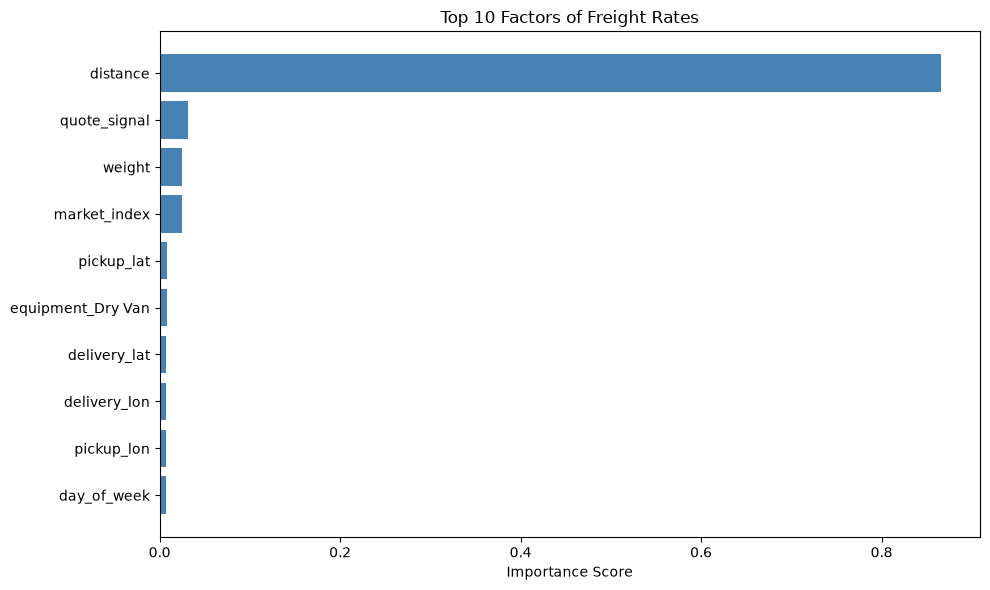

In [10]:
import matplotlib.pyplot as plt

# Extract feature importances from the trained model
importances = rf_model.feature_importances_

# Create a DataFrame to link column names with their importance scores
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Display the numerical ranking
print("Top 10 Most Important Features:")
print(importance_df.head(10).to_string(index=False))

# Generate a horizontal bar chart
plt.figure(figsize=(10, 6))
# Select the top 10
plt.barh(importance_df['Feature'][:10][::-1], importance_df['Importance'][:10][::-1], color='steelblue')
plt.xlabel('Importance Score')
plt.title('Top 10 Factors of Freight Rates')
plt.tight_layout()
plt.show()

In [17]:
def process_new_data(df, training_columns):
    # Create a copy to avoid modifying the original dataframe
    df_processed = df.copy()
    
    # Extract numerical time features
    df_processed['date'] = pd.to_datetime(df_processed['date'], format='mixed', dayfirst=True)
    df_processed['month'] = df_processed['date'].dt.month
    df_processed['day_of_week'] = df_processed['date'].dt.dayofweek
    
    # Apply One-Hot Encoding to equipment column
    if 'equipment' in df_processed.columns:
        df_processed = pd.get_dummies(df_processed, columns=['equipment'], dtype=int)
        
    # Drop text strings and identifiers
    cols_to_drop = ['load_id', 'pickup', 'delivery', 'date']
    df_processed = df_processed.drop(columns=[col for col in cols_to_drop if col in df_processed.columns])
    
    # Align columns to guarantee identical shapes for the model
    df_processed = df_processed.reindex(columns=training_columns, fill_value=0)
    
    return df_processed

# Save the exact column structure from the training phase
model_features = X_train.columns

In [12]:
# Load the required files
val_data = pd.read_csv('validation.csv')
template_df = pd.read_csv('validation-predictions-template.csv')

# Feature Extraction
X_test_final = process_new_data(val_data, model_features)

# Generate rate predictions using the trained model
test_predictions = rf_model.predict(X_test_final)

# Fill the predicted_rate column
template_df['predicted_rate'] = test_predictions

# Save the required file
template_df.to_csv('validation_predictions.csv', index=False)

print("Successfully created validation_predictions.csv")

Successfully created validation_predictions.csv


In [23]:
# Load original training data to calculate means and find coordinates
train_df_raw = pd.read_csv('train-test.csv')

# Calculate historical averages for market conditions
mean_market = train_df_raw['market_index'].mean()
mean_quote = train_df_raw['quote_signal'].mean()

# Extract exact coordinates dynamically
lexington_data = train_df_raw[train_df_raw['pickup'] == 'Lexington'].iloc[0]
fort_wayne_data = train_df_raw[train_df_raw['delivery'] == 'Fort Wayne'].iloc[0]

# Load the December file
dec_data = pd.read_csv('december-chart-inputs.csv')

# Inject the missing features into the December dataframe
dec_data['pickup_lat'] = lexington_data['pickup_lat']
dec_data['pickup_lon'] = lexington_data['pickup_lon']
dec_data['delivery_lat'] = fort_wayne_data['delivery_lat']
dec_data['delivery_lon'] = fort_wayne_data['delivery_lon']
dec_data['market_index'] = mean_market
dec_data['quote_signal'] = mean_quote

# Process through our reusable function
X_dec_final = process_new_data(dec_data, model_features)

# Generate predictions
dec_predictions = rf_model.predict(X_dec_final)
dec_data['predicted_rate'] = dec_predictions

# Convert DD/MM/YYYY to standard YYYY-MM-DD for score.py compatibility
dec_data['date'] = pd.to_datetime(dec_data['date'], format='mixed', dayfirst=True).dt.strftime('%Y-%m-%d')

final_december_output = dec_data[['pickup', 'delivery', 'distance', 'equipment', 'weight', 'date', 'predicted_rate']]

final_december_output.to_csv('december-chart-inputs.csv', index=False)

print("Successfully overwrote december-chart-inputs.csv with predictions.")

ValueError: time data "2025-12-01" doesn't match format "%d/%m/%Y", at position 0. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.